<a href="https://colab.research.google.com/github/MalavMDesai/GenAIAssignment/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [143]:
url="https://github.com/MalavMDesai/GenAIAssignment/raw/refs/heads/main/assignment2.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = pd.get_dummies(df, dtype=int, drop_first=True)
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(yes/no),EmploymentType_Self-Employed
0,28,6.5,720,5,5,0,0
1,45,12.0,680,10,10,1,1
2,35,8.0,750,6,7,0,0
3,50,15.0,640,12,15,1,1
4,30,7.0,710,5,5,0,0
5,42,10.0,660,9,10,1,0
6,26,5.5,730,4,4,0,0
7,48,14.0,650,11,12,1,1
8,38,9.0,700,7,8,0,0
9,55,16.0,620,13,15,1,1


In [144]:
features = df[['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)', 'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType_Self-Employed']]
target = df['loan(yes/no)']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

feature_train, feature_test, target_train, target_test = train_test_split(
    features_scaled,
    target,
    test_size=0.3,
    random_state=827
)
kModel = KNeighborsClassifier(n_neighbors=3)
kModel.fit(feature_train, target_train)

KNeighborsClassifier(n_neighbors=3)

In [145]:
dtModel = DecisionTreeClassifier(random_state=827)
dtModel.fit(feature_train, target_train)

DecisionTreeClassifier(random_state=827)

Text(0.5, 1.0, 'Confusion Matrix for KNN')

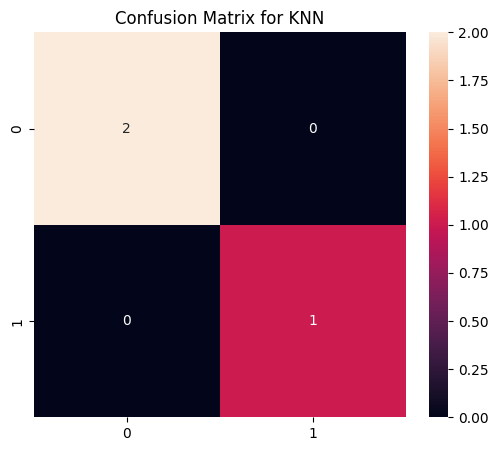

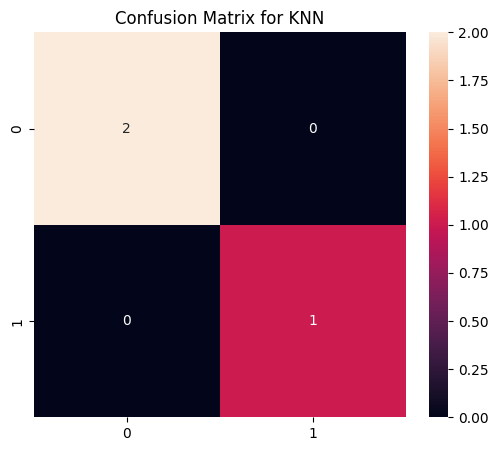

In [158]:
target_predicted = kModel.predict(feature_test)
kCm = confusion_matrix(target_test, target_predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(kCm, annot=True)
plt.title('Confusion Matrix for KNN')

target_predicted = dtModel.predict(feature_test)
dtCm = confusion_matrix(target_test, target_predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(kCm, annot=True)
plt.title('Confusion Matrix for DT')


In [147]:
newdf = df.iloc[[5]]
newdf.iloc[0,2]=600
newdf = pd.concat([newdf]*5,ignore_index=True)
for i in range(len(newdf)):
  #increasing Training hours by 2
  newdf.iloc[i,2] += i*50
print(newdf)
features = newdf[['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)', 'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType_Self-Employed']]
features_scaled = scaler.transform(features)
print(model.predict(features_scaled))

   Age  AnnualIncome(lakhs)  CreditScore(300-900)  LoanAmount(lakhs)  \
0   42                 10.0                   600                  9   
1   42                 10.0                   650                  9   
2   42                 10.0                   700                  9   
3   42                 10.0                   750                  9   
4   42                 10.0                   800                  9   

   LoanTerm(years)  loan(yes/no)  EmploymentType_Self-Employed  
0               10             1                             0  
1               10             1                             0  
2               10             1                             0  
3               10             1                             0  
4               10             1                             0  
[1 1 0 0 0]


In [148]:
newdf = df.iloc[[5]]
newdf.iloc[0,1]=6.0
newdf.iloc[0,2]=700
newdf = pd.concat([newdf]*5,ignore_index=True)
for i in range(len(newdf)):
  #increasing Training hours by 2
  newdf.iloc[i,1] += i*2
print(newdf)
features = newdf[['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)', 'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType_Self-Employed']]
features_scaled = scaler.transform(features)
print(model.predict(features_scaled))

   Age  AnnualIncome(lakhs)  CreditScore(300-900)  LoanAmount(lakhs)  \
0   42                  6.0                   700                  9   
1   42                  8.0                   700                  9   
2   42                 10.0                   700                  9   
3   42                 12.0                   700                  9   
4   42                 14.0                   700                  9   

   LoanTerm(years)  loan(yes/no)  EmploymentType_Self-Employed  
0               10             1                             0  
1               10             1                             0  
2               10             1                             0  
3               10             1                             0  
4               10             1                             0  
[0 0 0 1 1]
